In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/0212-cropped/0212_cropped.mp4
/kaggle/input/new-processed-csv-timestamp/processed_combined_tracking_data.csv
/kaggle/input/141-conflict-zone-annotated-polygons/141_conflict_zones_CEN300_PET.csv
/kaggle/input/video-cen300/0212.mp4


In [2]:
df = pd.read_csv(r'/kaggle/input/new-processed-csv-timestamp/processed_combined_tracking_data.csv')
df.rename(columns={
    'timestamp': 'Time',
    'frame_number': 'Frame_ID',
    'vehicle_id': 'Vehicle_ID',
    'x': 'X_central',
    'y': 'Y_central',
    'x1': 'X1_boundary',
    'y1': 'Y1_boundary',
    'x2': 'X3_boundary',
    'y2': 'Y3_boundary'
}, inplace=True)

In [3]:
df

,Time,Frame_ID,Vehicle_ID,X_central,Y_central,X1_boundary,Y1_boundary,X3_boundary,Y3_boundary
0,0.000000,0,1,323.753850,244.54315,318.220580,239.55382,329.28710,249.53250
1,0.000000,0,2,391.717830,275.67474,385.785250,270.32385,397.65040,281.02560
2,0.000000,0,3,401.334100,251.35030,393.590270,244.73557,409.07790,257.96503
3,0.000000,0,4,522.845700,234.48148,511.184140,226.27820,534.50720,242.68474
4,0.033333,1,2,390.745000,275.69020,384.814150,270.33154,396.67587,281.04886
...,...,...,...,...,...,...,...,...,...
6615,45.200000,1356,412,55.835953,304.38287,48.771217,298.37247,62.90069,310.39328
6616,45.200000,1356,402,293.596000,285.93573,287.697360,280.71014,299.49463,291.16132
6617,45.200000,1356,357,137.816040,297.97516,131.803470,292.35928,143.82863,303.59103
6618,45.200000,1356,360,759.087300,240.51747,749.301150,234.02133,768.87340,247.01361


In [4]:
import cv2

cap = cv2.VideoCapture('/kaggle/input/0212-cropped/0212_cropped.mp4')
ret, frame = cap.read()  # Read the first frame
cv2.imwrite("random_frame.jpg", frame)  # Save the frame

True

In [5]:
zone_df = pd.read_csv(r'/kaggle/input/141-conflict-zone-annotated-polygons/141_conflict_zones_CEN300_PET.csv')
zone_df

,zone_id,region_shape_attributes
0,1,"{""name"":""polyline"",""all_points_x"":[388,414,414..."
1,2,"{""name"":""polyline"",""all_points_x"":[415,415,442..."
2,3,"{""name"":""polyline"",""all_points_x"":[415,415,442..."
3,4,"{""name"":""polyline"",""all_points_x"":[443,443,470..."
4,5,"{""name"":""polyline"",""all_points_x"":[388,414,414..."
...,...,...
136,137,"{""name"":""polyline"",""all_points_x"":[63,83,83,63..."
137,138,"{""name"":""polyline"",""all_points_x"":[63,84,84,63..."
138,139,"{""name"":""polyline"",""all_points_x"":[39,60,60,39..."
139,140,"{""name"":""polyline"",""all_points_x"":[39,61,61,39..."


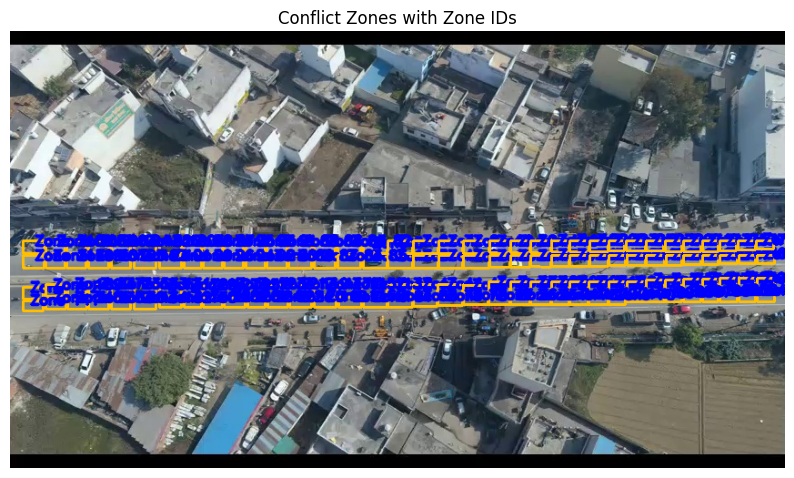

In [6]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import cv2

# Load image
image_path = '/kaggle/working/random_frame.jpg'
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Draw polygons and overlay zone IDs
for idx, row in zone_df.iterrows():
    try:
        shape = json.loads(row['region_shape_attributes'])  # Properly parsed

        all_x = shape['all_points_x']
        all_y = shape['all_points_y']
        points = list(zip(all_x, all_y))
        pts_np = np.array(points, np.int32).reshape((-1, 1, 2))

        # Draw polygon
        cv2.polylines(image, [pts_np], isClosed=True, color=(255, 191, 0), thickness=2)

        # Put zone_id text at the centroid
        centroid_x = int(np.mean(all_x))
        centroid_y = int(np.mean(all_y))
        zone_id = str(row['zone_id'])

        cv2.putText(image, f"Zone {zone_id}", (centroid_x, centroid_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2, cv2.LINE_AA)

    except Exception as e:
        print(f"⚠️ Error parsing row {idx}: {e}")

# Show result
plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.title("Conflict Zones with Zone IDs")
plt.axis('off')
plt.show()


In [7]:
!pip install shapely matplotlib  # Install required packages

In [8]:
from shapely.geometry import Polygon, Point
import json

conflict_zones = []

for _, row in zone_df.iterrows():
    shape = json.loads(row['region_shape_attributes'].replace("'", '"'))
    
    all_x = shape['all_points_x']
    all_y = shape['all_points_y']
    
    coords = list(zip(all_x, all_y))
    poly = Polygon(coords)
    conflict_zones.append({
        'name': row['zone_id'],  # or give a zone_id
        'polygon': poly
    })

In [9]:
conflict_zones

[{'name': 1,
  'polygon': <POLYGON ((388 246, 414 246, 414 260, 388 260, 388 246))>},
 {'name': 2,
  'polygon': <POLYGON ((415 246, 415 260, 442 260, 442 246, 415 246))>},
 {'name': 3,
  'polygon': <POLYGON ((415 246, 415 260, 442 260, 442 246, 415 246))>},
 {'name': 4,
  'polygon': <POLYGON ((443 246, 443 260, 470 260, 470 246, 443 246))>},
 {'name': 5,
  'polygon': <POLYGON ((388 243, 414 244, 414 230, 388 229, 388 243))>},
 {'name': 6,
  'polygon': <POLYGON ((415 230, 442 230, 442 244, 415 244, 415 230))>},
 {'name': 7,
  'polygon': <POLYGON ((443 230, 470 230, 470 244, 443 244, 443 230))>},
 {'name': 8,
  'polygon': <POLYGON ((471 230, 471 244, 497 244, 497 230, 471 230))>},
 {'name': 9,
  'polygon': <POLYGON ((471 246, 497 246, 497 260, 471 260, 471 246))>},
 {'name': 10,
  'polygon': <POLYGON ((498 230, 526 230, 526 244, 498 244, 498 230))>},
 {'name': 11,
  'polygon': <POLYGON ((498 246, 526 246, 526 260, 498 260, 498 246))>},
 {'name': 12,
  'polygon': <POLYGON ((527 230, 549 2

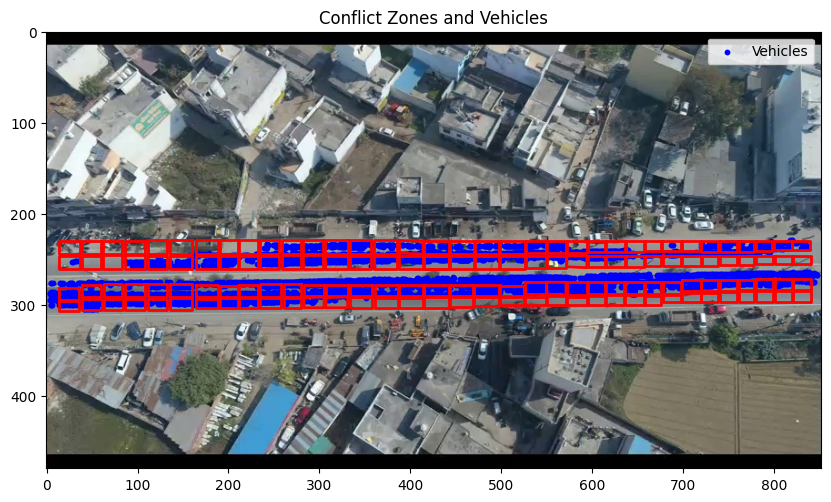

In [10]:
import matplotlib.pyplot as plt

# Sample frame image
frame = cv2.imread("/kaggle/working/random_frame.jpg")  # or use from cap.read()

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# Plot conflict zones
for zone in conflict_zones:
    x, y = zone['polygon'].exterior.xy
    plt.plot(x, y, color='red', linewidth=2)

# Plot vehicle centers
plt.scatter(df['X_central'], df['Y_central'], s=10, c='blue', label='Vehicles')

plt.legend()
plt.title("Conflict Zones and Vehicles")
plt.show()

In [11]:
def get_conflict_zone_id(row, zones):
    vehicle_center = Point(row['X_central'], row['Y_central'])
    for zone in zones:
        if zone['polygon'].contains(vehicle_center):
            return zone['name']  # Return the zone ID
    return None  # If not in any zone

# Apply to DataFrame
df['Conflict_Zone_ID'] = df.apply(get_conflict_zone_id, zones=conflict_zones, axis=1)

# Optional: also keep a flag column
df['In_Conflict_Zone'] = df['Conflict_Zone_ID'].notnull()

# Get only entries in any conflict zone
conflict_entries = df[df['In_Conflict_Zone']]
conflict_entries = conflict_entries[['Time', 'Vehicle_ID', 'X_central', 'Y_central', 'Conflict_Zone_ID']]  

In [12]:
conflict_entries

,Time,Vehicle_ID,X_central,Y_central,Conflict_Zone_ID
2,0.000000,3,401.334100,251.35030,1.0
3,0.000000,4,522.845700,234.48148,10.0
6,0.033333,4,523.083600,234.58981,10.0
7,0.033333,3,401.918950,251.33287,1.0
10,0.066667,4,523.669430,234.75000,10.0
...,...,...,...,...,...
6612,45.200000,373,662.451970,285.31244,53.0
6613,45.200000,328,230.887330,279.75122,125.0
6615,45.200000,412,55.835953,304.38287,140.0
6616,45.200000,402,293.596000,285.93573,119.0


In [13]:
unique = conflict_entries[['Vehicle_ID', 'Conflict_Zone_ID']].drop_duplicates()
unique

,Vehicle_ID,Conflict_Zone_ID
2,3,1.0
3,4,10.0
15,5,42.0
20,7,13.0
35,11,58.0
...,...,...
6509,360,33.0
6536,414,8.0
6589,373,53.0
6596,402,119.0


In [14]:
df['Conflict_Zone_ID'] = df['Conflict_Zone_ID'].fillna(-1)

In [15]:
df

,Time,Frame_ID,Vehicle_ID,X_central,Y_central,X1_boundary,Y1_boundary,X3_boundary,Y3_boundary,Conflict_Zone_ID,In_Conflict_Zone
0,0.000000,0,1,323.753850,244.54315,318.220580,239.55382,329.28710,249.53250,-1.0,False
1,0.000000,0,2,391.717830,275.67474,385.785250,270.32385,397.65040,281.02560,-1.0,False
2,0.000000,0,3,401.334100,251.35030,393.590270,244.73557,409.07790,257.96503,1.0,True
3,0.000000,0,4,522.845700,234.48148,511.184140,226.27820,534.50720,242.68474,10.0,True
4,0.033333,1,2,390.745000,275.69020,384.814150,270.33154,396.67587,281.04886,-1.0,False
...,...,...,...,...,...,...,...,...,...,...,...
6615,45.200000,1356,412,55.835953,304.38287,48.771217,298.37247,62.90069,310.39328,140.0,True
6616,45.200000,1356,402,293.596000,285.93573,287.697360,280.71014,299.49463,291.16132,119.0,True
6617,45.200000,1356,357,137.816040,297.97516,131.803470,292.35928,143.82863,303.59103,132.0,True
6618,45.200000,1356,360,759.087300,240.51747,749.301150,234.02133,768.87340,247.01361,-1.0,False


In [16]:
df[['Frame_ID','Vehicle_ID']]
#Tracking already done

,Frame_ID,Vehicle_ID
0,0,1
1,0,2
2,0,3
3,0,4
4,1,2
...,...,...
6615,1356,412
6616,1356,402
6617,1356,357
6618,1356,360


In [17]:
conflict_log = []

for track_id in conflict_entries['Vehicle_ID'].dropna().unique():
    track = conflict_entries[conflict_entries['Vehicle_ID'] == track_id].sort_values('Time')

    for zone_id in track['Conflict_Zone_ID'].dropna().unique():
        zone_track = track[track['Conflict_Zone_ID'] == zone_id]
        in_zone = False
        entry_time = None

        for i, (_, row) in enumerate(zone_track.iterrows()):
            if row['Conflict_Zone_ID'] == zone_id and not in_zone:
                entry_time = row['Time']
                in_zone = True
            elif row['Conflict_Zone_ID'] != zone_id and in_zone:
                exit_time = row['Time']
                conflict_log.append({
                    'Vehicle_ID': track_id,
                    'Conflict_Zone_ID': zone_id,
                    'entry_time': entry_time,
                    'exit_time': exit_time,
                    'duration': exit_time - entry_time
                })
                in_zone = False

            if in_zone and i == len(zone_track) - 1:
                conflict_log.append({
                    'Vehicle_ID': track_id,
                    'Conflict_Zone_ID': zone_id,
                    'entry_time': entry_time,
                    'exit_time': row['Time'],  # last available time
                    'duration': row['Time'] - entry_time
                })
                in_zone = False  # Reset to avoid duplicates

In [18]:
conflict_log = pd.DataFrame(conflict_log).sort_values('Vehicle_ID')
conflict_log

,Vehicle_ID,Conflict_Zone_ID,entry_time,exit_time,duration
35,1,85.0,1.100000,1.533333,0.433333
37,1,2.0,2.533333,2.700000,0.166667
36,1,1.0,1.733333,2.400000,0.666667
34,1,84.0,0.866667,0.900000,0.033333
70,2,121.0,1.933333,1.966667,0.033333
...,...,...,...,...,...
450,410,99.0,44.600000,44.733333,0.133333
451,410,96.0,44.800000,44.900000,0.100000
452,412,140.0,44.666667,45.200000,0.533333
453,413,122.0,44.766667,44.966667,0.200000


In [19]:
pet_data = []

if not conflict_log.empty:
    conflict_log = conflict_log.sort_values(['Conflict_Zone_ID', 'exit_time'])

    for zone_id in conflict_log['Conflict_Zone_ID'].unique():
        conflict_df = conflict_log[conflict_log['Conflict_Zone_ID'] == zone_id].sort_values('exit_time').reset_index(drop=True)

        for i in range(1, len(conflict_df)):
            prev = conflict_df.iloc[i-1]
            curr = conflict_df.iloc[i]

            pet = curr['entry_time'] - prev['exit_time']

            pet_data.append({
                'zone_id': zone_id,
                'leading_vehicle': prev['Vehicle_ID'],
                'following_vehicle': curr['Vehicle_ID'],
                'pet': pet
            })

    pet_df = pd.DataFrame(pet_data)
else:
    print("⚠️ No conflicts to calculate PET from.")
    pet_df = pd.DataFrame()

In [20]:
pet_df

,zone_id,leading_vehicle,following_vehicle,pet
0,1.0,3.0,1.0,1.433333
1,1.0,1.0,66.0,7.333333
2,1.0,66.0,184.0,7.833333
3,1.0,184.0,321.0,15.933333
4,1.0,321.0,320.0,5.266667
...,...,...,...,...
351,139.0,279.0,346.0,15.733333
352,140.0,28.0,5.0,1.466667
353,140.0,5.0,31.0,5.500000
354,140.0,31.0,218.0,17.833333


In [21]:
def categorize_pet(pet):
    if pet <= 0:
        return 'Near-Miss'
    elif pet <= 1.5:
        return 'High Risk'
    elif pet <= 3.0:
        return 'Moderate Risk'
    elif pet <= 5.0:
        return 'Low Risk'
    else:
        return 'Safe'

pet_df['risk_category'] = pet_df['pet'].apply(categorize_pet)

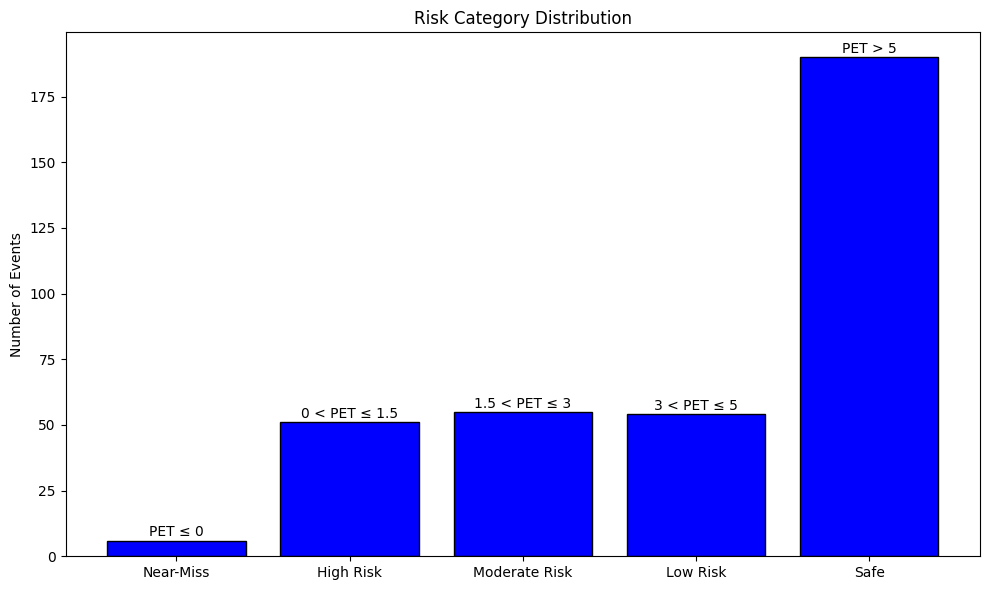

In [22]:
# Count categories
category_counts = pet_df['risk_category'].value_counts().reindex([
    "Near-Miss", "High Risk", "Moderate Risk", "Low Risk", "Safe"
], fill_value=0)

colors = ['blue', 'blue', 'blue', 'blue', 'blue']
labels = [
    "PET ≤ 0", "0 < PET ≤ 1.5", "1.5 < PET ≤ 3", "3 < PET ≤ 5", "PET > 5"
]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(category_counts.index, category_counts.values, color=colors, edgecolor='black')

# Annotate with PET condition
for bar, label in zip(bars, labels):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, label,
             ha='center', va='bottom', fontsize=10)

plt.ylabel('Number of Events')
plt.title('Risk Category Distribution')
plt.xticks()
plt.tight_layout()
plt.show()

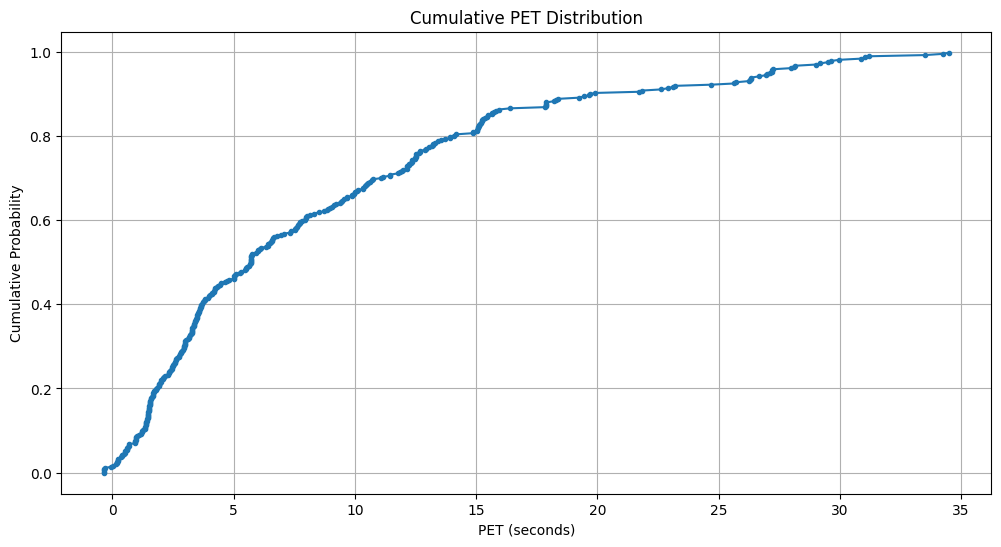

In [23]:
pet_sorted = pet_df['pet'].sort_values()
cdf = np.arange(len(pet_sorted)) / len(pet_sorted)

plt.figure(figsize=(12, 6))

plt.plot(pet_sorted, cdf, marker='.', linestyle='-')
plt.xlabel('PET (seconds)')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative PET Distribution')
plt.grid(True)
plt.show()

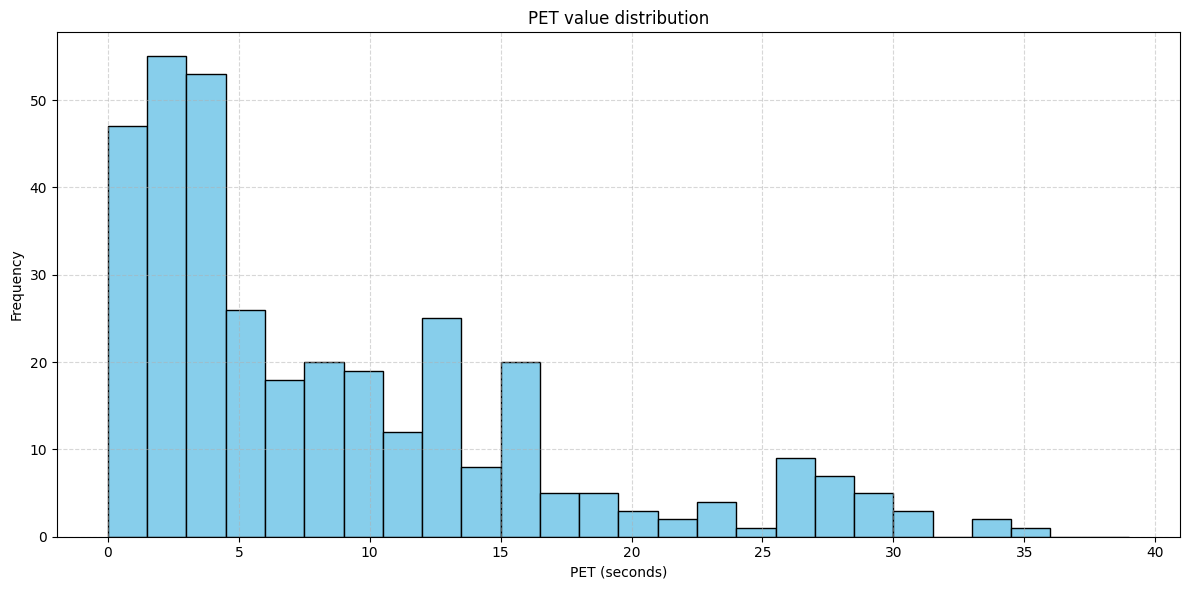

In [24]:
plt.figure(figsize=(12, 6))
bins = np.arange(0, pet_df['pet'].max() + 5, 1.5)

plt.hist(pet_df['pet'], bins=bins, color='skyblue', edgecolor='black')
plt.xlabel('PET (seconds)')
plt.ylabel('Frequency')
plt.title('PET value distribution')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [25]:
for p in [25, 50, 75, 90]:
    print(f"{p}th percentile PET: {np.percentile(pet_df['pet'], p):.2f} seconds")

25th percentile PET: 2.47 seconds
50th percentile PET: 5.70 seconds
75th percentile PET: 12.47 seconds
90th percentile PET: 19.67 seconds


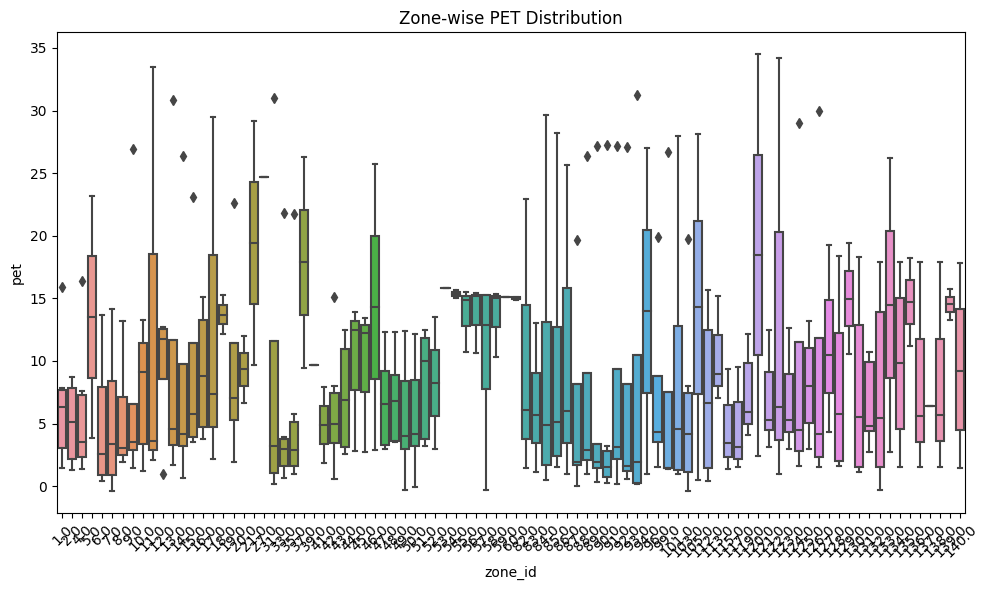

In [26]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x='zone_id', y='pet', data=pet_df)
plt.xticks(rotation=45)
plt.title("Zone-wise PET Distribution")
plt.tight_layout()
plt.show()

In [27]:
pet_df

,zone_id,leading_vehicle,following_vehicle,pet,risk_category
0,1.0,3.0,1.0,1.433333,High Risk
1,1.0,1.0,66.0,7.333333,Safe
2,1.0,66.0,184.0,7.833333,Safe
3,1.0,184.0,321.0,15.933333,Safe
4,1.0,321.0,320.0,5.266667,Safe
...,...,...,...,...,...
351,139.0,279.0,346.0,15.733333,Safe
352,140.0,28.0,5.0,1.466667,High Risk
353,140.0,5.0,31.0,5.500000,Safe
354,140.0,31.0,218.0,17.833333,Safe


In [28]:
df

,Time,Frame_ID,Vehicle_ID,X_central,Y_central,X1_boundary,Y1_boundary,X3_boundary,Y3_boundary,Conflict_Zone_ID,In_Conflict_Zone
0,0.000000,0,1,323.753850,244.54315,318.220580,239.55382,329.28710,249.53250,-1.0,False
1,0.000000,0,2,391.717830,275.67474,385.785250,270.32385,397.65040,281.02560,-1.0,False
2,0.000000,0,3,401.334100,251.35030,393.590270,244.73557,409.07790,257.96503,1.0,True
3,0.000000,0,4,522.845700,234.48148,511.184140,226.27820,534.50720,242.68474,10.0,True
4,0.033333,1,2,390.745000,275.69020,384.814150,270.33154,396.67587,281.04886,-1.0,False
...,...,...,...,...,...,...,...,...,...,...,...
6615,45.200000,1356,412,55.835953,304.38287,48.771217,298.37247,62.90069,310.39328,140.0,True
6616,45.200000,1356,402,293.596000,285.93573,287.697360,280.71014,299.49463,291.16132,119.0,True
6617,45.200000,1356,357,137.816040,297.97516,131.803470,292.35928,143.82863,303.59103,132.0,True
6618,45.200000,1356,360,759.087300,240.51747,749.301150,234.02133,768.87340,247.01361,-1.0,False


In [29]:
zone_df

,zone_id,region_shape_attributes
0,1,"{""name"":""polyline"",""all_points_x"":[388,414,414..."
1,2,"{""name"":""polyline"",""all_points_x"":[415,415,442..."
2,3,"{""name"":""polyline"",""all_points_x"":[415,415,442..."
3,4,"{""name"":""polyline"",""all_points_x"":[443,443,470..."
4,5,"{""name"":""polyline"",""all_points_x"":[388,414,414..."
...,...,...
136,137,"{""name"":""polyline"",""all_points_x"":[63,83,83,63..."
137,138,"{""name"":""polyline"",""all_points_x"":[63,84,84,63..."
138,139,"{""name"":""polyline"",""all_points_x"":[39,60,60,39..."
139,140,"{""name"":""polyline"",""all_points_x"":[39,61,61,39..."


In [30]:
from ast import literal_eval
from collections import defaultdict

# Parse region_shape_attributes
if isinstance(zone_df["region_shape_attributes"].iloc[0], str):
    zone_df["region_shape_attributes"] = zone_df["region_shape_attributes"].apply(literal_eval)
    
# Map of zone_id -> polygon points
zone_polygons = {}
for _, row in zone_df.iterrows():
    zone_id = int(row["zone_id"])
    attrs = row["region_shape_attributes"]
    points = list(zip(attrs["all_points_x"], attrs["all_points_y"]))
    zone_polygons[zone_id] = points

# Risk color map
risk_colors = {
    "High Risk": (0, 0, 255),    # Red
    "Near-Miss": (0, 0, 255),    # Red
    "Moderate": (0, 165, 255),   # Orange
    "Safe": (0, 255, 0),         # Green
}

# Set zone risk display values (initial values)
zone_pet_display = {}
for zone_id in pet_df["zone_id"].unique():
    zone_rows = pet_df[pet_df["zone_id"] == zone_id]
    highest_risk = zone_rows.sort_values("pet").iloc[0]
    zone_pet_display[zone_id] = {
        "pet": round(highest_risk["pet"], 2),
        "risk_category": highest_risk["risk_category"]
    }

# Track current zone PET value
current_zone_pet = zone_pet_display.copy()

# Read video
video_path = "/kaggle/input/0212-cropped/0212_cropped.mp4"
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("annotated_output.mp4", fourcc, fps, (width, height))

frame_id = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_vehicles = df[df["Frame_ID"] == frame_id]

    # Draw zones
    for zone_id, points in zone_polygons.items():
        display_pet = current_zone_pet.get(zone_id, {})
        category = display_pet.get("risk_category", "Safe")
        color = risk_colors.get(category, (255, 255, 255))

        pts = np.array(points, dtype=np.int32)
        cv2.polylines(frame, [pts], isClosed=True, color=color, thickness=2)

        if display_pet:
            text = f"Zone {zone_id}: PET={display_pet['pet']}, Risk={display_pet['risk_category']}"
            pos = tuple(points[0])
            cv2.putText(frame, text, pos, cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)

    # Draw vehicle boxes
    for _, row in frame_vehicles.iterrows():
        vehicle_id = int(row["Vehicle_ID"])
        x1, y1, x2, y2 = int(row["X1_boundary"]), int(row["Y1_boundary"]), int(row["X3_boundary"]), int(row["Y3_boundary"])
        cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 255, 0), 2)
        cv2.putText(frame, f"ID:{vehicle_id}", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)

    # Check if PET value changed for any zone (based on new vehicle pair entering)
    for _, pet_row in pet_df.iterrows():
        zone_id = int(pet_row["zone_id"])
        lead = int(pet_row["leading_vehicle"])
        follow = int(pet_row["following_vehicle"])

        lead_present = lead in frame_vehicles["Vehicle_ID"].values
        follow_present = follow in frame_vehicles["Vehicle_ID"].values

        if lead_present or follow_present:
            existing_pet = current_zone_pet.get(zone_id, {}).get("pet")
            new_pet = round(pet_row["pet"], 2)
            if existing_pet != new_pet:
                current_zone_pet[zone_id] = {
                    "pet": new_pet,
                    "risk_category": pet_row["risk_category"]
                }

    out.write(frame)
    frame_id += 1

cap.release()
out.release()
cv2.destroyAllWindows()

In [31]:
def generate_pet_heatmap(df, pet_df, width, height):
    heatmap_data = np.zeros((height, width), dtype=np.float32)

    risk_weights = {
        'Near-Miss': 1.0**2,
        'High Risk': 0.8**2,
        'Moderate Risk': 0.6**2,
        'Low Risk': 0.4**2,
        'Safe': 0.2**2
    }

    for _, pet_row in pet_df.iterrows():
        lead_id = pet_row['leading_vehicle']
        follow_id = pet_row['following_vehicle']
        risk = pet_row['risk_category']
        weight = risk_weights.get(risk, 0.2**2) # default to 0.2 if missing

        lead_frames = df[df['Vehicle_ID'] == lead_id]
        follow_frames = df[df['Vehicle_ID'] == follow_id]

        common_frames = np.intersect1d(lead_frames['Frame_ID'], follow_frames['Frame_ID'])

        for frame_num in common_frames:
            lead_box = lead_frames[lead_frames['Frame_ID'] == frame_num]
            follow_box = follow_frames[follow_frames['Frame_ID'] == frame_num]

            if lead_box.empty or follow_box.empty:
                continue

            def center_of_box(row):
                x = int(row['X_central'].values[0])
                y = int(row['Y_central'].values[0])
                return x, y

            x1, y1 = center_of_box(lead_box)
            x2, y2 = center_of_box(follow_box)

            cv2.circle(heatmap_data, (x1, y1), 5, weight, -1)
            cv2.circle(heatmap_data, (x2, y2), 5, weight, -1)

    heatmap_data = cv2.GaussianBlur(heatmap_data, (0, 0), sigmaX=10, sigmaY=10)
    
    heatmap_data = np.clip(heatmap_data, 0.05, 1.0)  # remove very faint values
    heatmap_data = (heatmap_data - 0.05) / (1.0 - 0.05)  # rescale to [0,1]
    
    return heatmap_data


# === Step 2: Load video ===
video_path = "/kaggle/input/0212-cropped/0212_cropped.mp4"
cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("output_with_heatmap.mp4", fourcc, fps, (width, height))

# === Step 3: Generate heatmap ===
heatmap_data = generate_pet_heatmap(df, pet_df, width, height)

# Normalize and convert to color
normalized_heatmap = cv2.normalize(heatmap_data, None, 0, 255, cv2.NORM_MINMAX)
colored_heatmap = cv2.applyColorMap(normalized_heatmap.astype(np.uint8), cv2.COLORMAP_JET)

# === Step 4: Overlay on video frames ===
alpha = 0.6  # heatmap transparency

def draw_heatmap_legend(frame, x=20, y=5, width=20, height=20):
    legend_colors = {
    'Near-Miss': (0, 0, 255),         # Red
    'High Risk': (0, 69, 255),        # Orange-Red
    'Moderate Risk': (0, 255, 255),   # Yellow
    'Low Risk': (255, 255, 0),        # Cyan
    'Safe': (255, 0, 0)               # Blue
    }

    gap = height + 5  # vertical spacing
    start_y = y

    for label, color in legend_colors.items():
        end_y = start_y + height
        cv2.rectangle(frame, (x, start_y), (x + width, end_y), color, -1)
        cv2.putText(frame, label, (x + width + 10, start_y + height // 2 + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
        start_y += gap

    return frame

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break


    if colored_heatmap.shape[:2] != frame.shape[:2]:
        colored_heatmap = cv2.resize(colored_heatmap, (frame.shape[1], frame.shape[0]))
    
    overlay = cv2.addWeighted(colored_heatmap, alpha, frame, 1 - alpha, 0)
    overlay = draw_heatmap_legend(overlay)  # Add legend after blending
    
    out.write(overlay)

cap.release()
out.release()
cv2.destroyAllWindows()